# Processed Data Verification & EDA
This notebook verifies the integrity of the modular Parquet components and performs basic EDA on the engineered technical features.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
# import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.data.data_module import DataModule

### 1. Load Modular Components via DataModule

In [2]:
PROCESSED_DIR = "../data/processed_market"
dm = DataModule(PROCESSED_DIR)

# Load and join features, targets, and metadata
df = dm.prepare_dataset(components=["technical_features", "targets", "metadata"])
df.sort_index(inplace=True)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset prepared successfully: 61991 rows.
Dataset loaded: 61991 rows, 62 columns


,Ret_Open,Ret_High,Ret_Low,Ret_Close,Ret_Vol,TRIX_30_9,VWAP_D,ROC_10,ATRr_14,MFI_14,...,Target_24h_1.0x_TBM,Target_24h_1.5x_TBM,Target_24h_2.0x_TBM,Target_24h_2.5x_TBM,Target_24h_3.0x_TBM,Open,High,Low,Close,Volume
time,,,,,,,,,,,,,,,,,,,,,
2016-04-21 04:00:00+00:00,-0.000319,0.000115,0.000425,-0.000212,0.256770,0.001853,1.129675,-0.081404,0.001179,18.497263,...,0.0,0.0,0.0,0.0,0.0,1.12948,1.12961,1.12900,1.12924,2599
2016-04-21 05:00:00+00:00,-0.000212,0.000496,0.000310,0.000372,0.350135,0.001135,1.129633,0.051369,0.001159,28.113564,...,0.0,0.0,0.0,0.0,0.0,1.12924,1.12980,1.12889,1.12966,3509
2016-04-21 06:00:00+00:00,0.000372,0.000620,0.000567,0.000133,0.994300,0.000449,1.129659,0.025675,0.001172,41.191519,...,0.0,0.0,0.0,0.0,0.0,1.12966,1.13036,1.12902,1.12981,6998
2016-04-21 07:00:00+00:00,0.000106,0.001106,0.000814,-0.000505,0.398685,-0.000215,1.129671,-0.064605,0.001244,39.097516,...,0.0,0.0,0.0,0.0,0.0,1.12978,1.13103,1.12886,1.12921,9788
2016-04-21 08:00:00+00:00,-0.000505,0.000469,0.000824,0.000044,-0.063343,-0.000853,1.129552,-0.073445,0.001259,36.545010,...,0.0,0.0,0.0,0.0,0.0,1.12921,1.12974,1.12828,1.12926,9168


In [3]:
for c in df.columns:
    if c.startswith("Target"):
        print(c)

Target_5h_Nguyen
Target_5h_1.0x_TBM
Target_5h_1.5x_TBM
Target_5h_2.0x_TBM
Target_5h_2.5x_TBM
Target_5h_3.0x_TBM
Target_12h_Nguyen
Target_12h_1.0x_TBM
Target_12h_1.5x_TBM
Target_12h_2.0x_TBM
Target_12h_2.5x_TBM
Target_12h_3.0x_TBM
Target_24h_Nguyen
Target_24h_1.0x_TBM
Target_24h_1.5x_TBM
Target_24h_2.0x_TBM
Target_24h_2.5x_TBM
Target_24h_3.0x_TBM


In [4]:
# Calculate class distribution for each target column
for col in df.columns:
    if col.startswith("Target"):
        print(f"\nDistribution for {col}:")
        counts = df[col].value_counts(normalize=True).sort_index()
        labels = ["Buy (0)", "Sell (1)", "Neutral (2)"]
        for i, val in enumerate(counts):
            print(f"  {labels[i]}: {val:.2%}")


Distribution for Target_5h_Nguyen:
  Buy (0): 34.85%
  Sell (1): 30.16%
  Neutral (2): 35.00%

Distribution for Target_5h_1.0x_TBM:
  Buy (0): 36.65%
  Sell (1): 38.02%
  Neutral (2): 25.33%

Distribution for Target_5h_1.5x_TBM:
  Buy (0): 25.35%
  Sell (1): 26.19%
  Neutral (2): 48.47%

Distribution for Target_5h_2.0x_TBM:
  Buy (0): 16.79%
  Sell (1): 17.50%
  Neutral (2): 65.71%

Distribution for Target_5h_2.5x_TBM:
  Buy (0): 11.12%
  Sell (1): 11.48%
  Neutral (2): 77.41%

Distribution for Target_5h_3.0x_TBM:
  Buy (0): 7.46%
  Sell (1): 7.63%
  Neutral (2): 84.91%

Distribution for Target_12h_Nguyen:
  Buy (0): 34.79%
  Sell (1): 30.34%
  Neutral (2): 34.86%

Distribution for Target_12h_1.0x_TBM:
  Buy (0): 47.09%
  Sell (1): 48.14%
  Neutral (2): 4.77%

Distribution for Target_12h_1.5x_TBM:
  Buy (0): 40.76%
  Sell (1): 41.37%
  Neutral (2): 17.87%

Distribution for Target_12h_2.0x_TBM:
  Buy (0): 32.68%
  Sell (1): 33.36%
  Neutral (2): 33.96%

Distribution for Target_12h_2.5x

### 2. Alignment & Integrity Sanity Checks

In [5]:
# 1. Check for missing values (there should be none after processing)
nan_counts = df.isna().sum().sum()
print(f"Total NaNs in dataset: {nan_counts}")

# 2. Check time continuity (hourly data)
time_diffs = df.index.to_series().diff().dt.total_seconds() / 3600
print(f"Max time gap: {time_diffs.max()} hours")
print(f"Average time gap (excluding weekends): {time_diffs[time_diffs < 48].mean():.2f} hours")

# 3. Target Distribution
target_col = "Target_5h_TBM"
if target_col in df.columns:
    print(f"\nDistribution for {target_col}:")
    counts = df[target_col].value_counts(normalize=True).sort_index()
    labels = ["Profit (0)", "Loss (1)", "Timeout (2)"]
    for i, val in enumerate(counts):
        print(f"  {labels[i]}: {val:.2%}")

Total NaNs in dataset: 0
Max time gap: 76.0 hours
Average time gap (excluding weekends): 1.00 hours


### 3. Visualizing Technical Indicators & Price

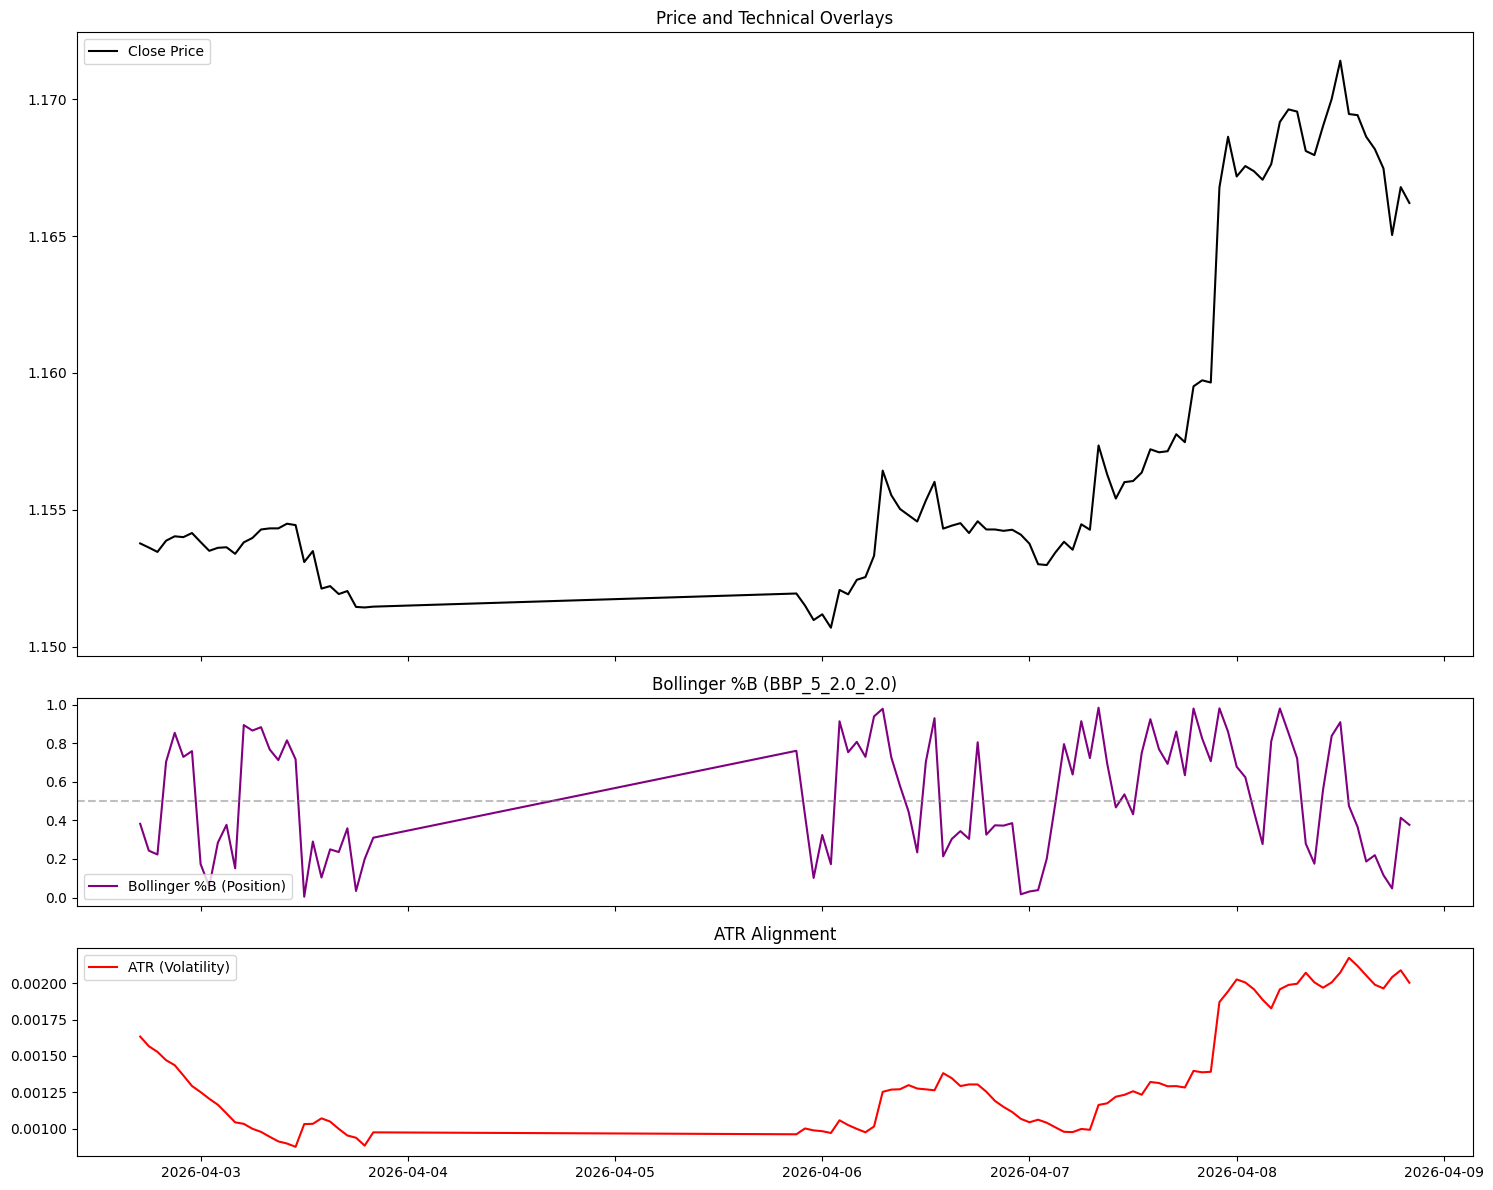

In [6]:
# Plot last 100 periods for visual confirmation of ATR and Bollinger Band features
plot_df = df.tail(100)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# Price Plot
ax1.plot(plot_df.index, plot_df['Close'], label='Close Price', color='black')
ax1.set_title("Price and Technical Overlays")
ax1.legend()

# Bollinger %B (BBP) - Stationary relative position
bb_col = [c for c in df.columns if "BBP" in c][0] if any("BBP" in c for c in df.columns) else None
if bb_col:
    ax2.plot(plot_df.index, plot_df[bb_col], label='Bollinger %B (Position)', color='purple')
    ax2.axhline(0.5, linestyle='--', color='gray', alpha=0.5)
    ax2.set_title(f"Bollinger %B ({bb_col})")
    ax2.legend()

# ATR Plot
if 'ATRr_14' in df.columns:
    ax3.plot(plot_df.index, plot_df['ATRr_14'], label='ATR (Volatility)', color='red')
    ax3.set_title("ATR Alignment")
    ax3.legend()

plt.tight_layout()
plt.show()

### 4. Indicator Correlation Matrix

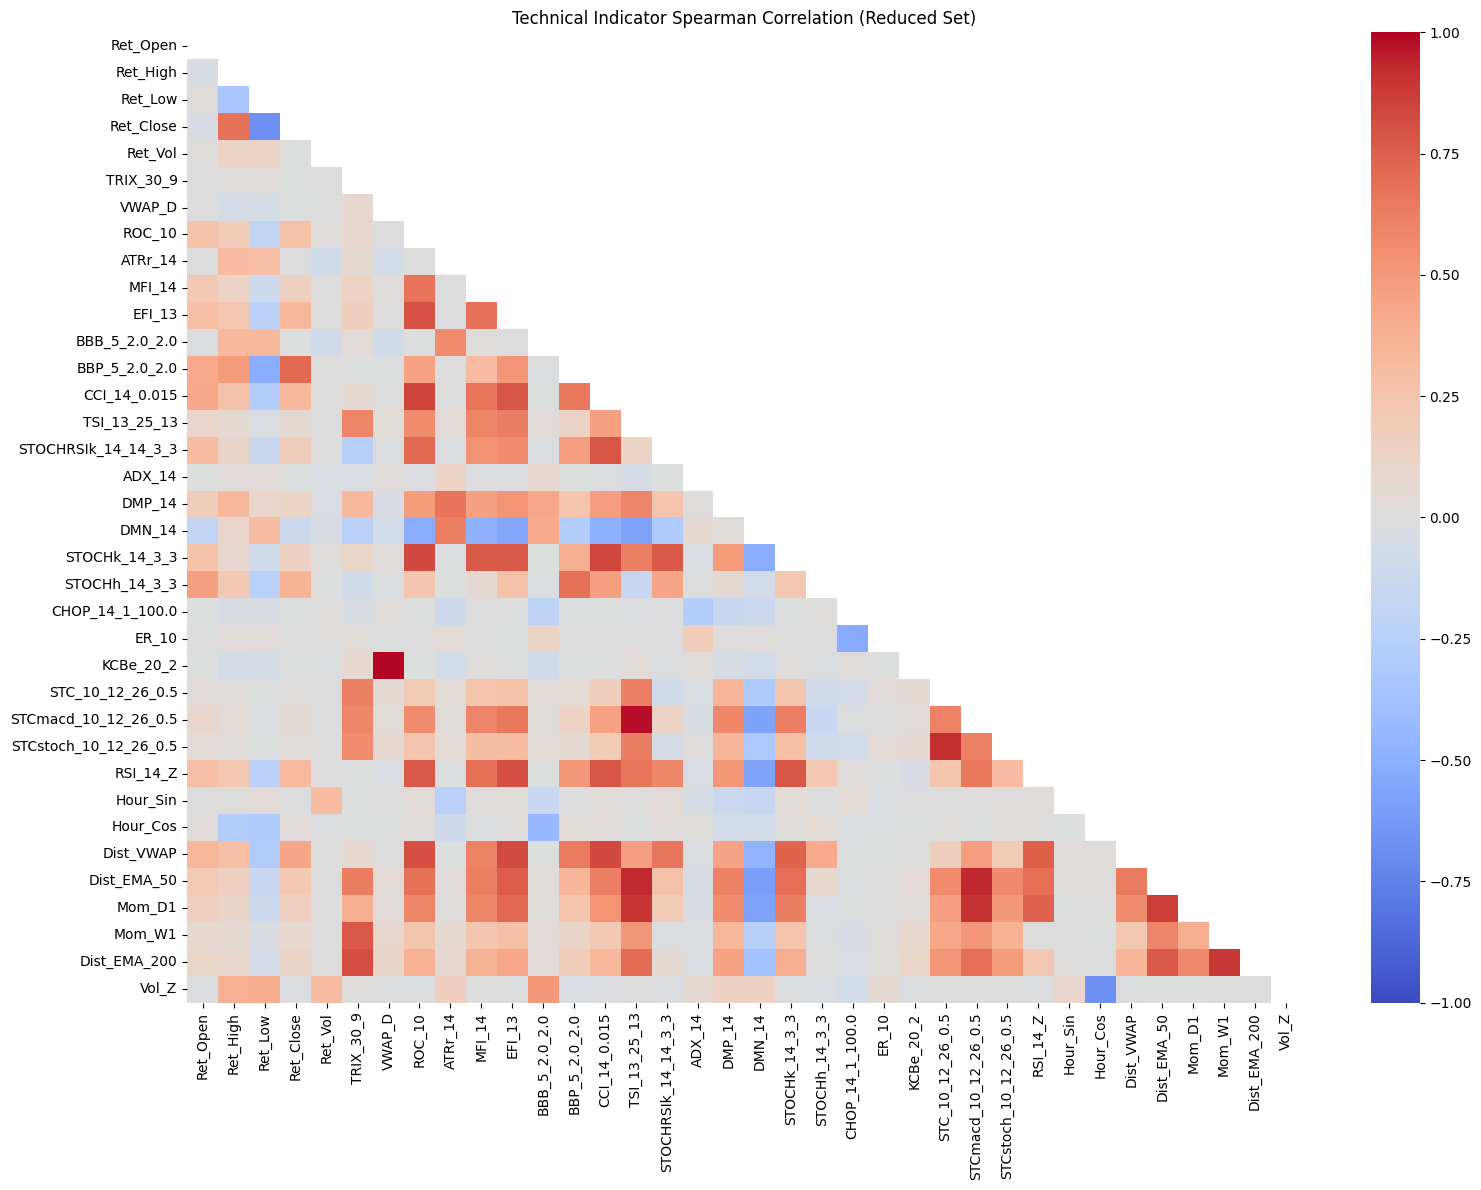

In [7]:
target_cols = [c for c in df.columns if "Target" in c or "LogRet" in c]
metadata_cols = ["Open", "High", "Low", "Close", "Volume"]
indicator_cols = [col for col in df.columns if col not in target_cols and col not in metadata_cols]

plt.figure(figsize=(16, 12))
corr_matrix = df[indicator_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Technical Indicator Spearman Correlation (Reduced Set)")
plt.tight_layout()
plt.show()